# [Вступ. Еволюція Data Science](https://www.edu.goit.global/learn/25315460/17003531/30287572/homework)
- Kaggle competition: [Test Task for DS - NLP 2025-04](https://www.kaggle.com/competitions/test-task-for-ds-nlp-2025-04/leaderboard)
- Dataset: [Dataset Description](https://www.kaggle.com/competitions/test-task-for-ds-nlp-2025-04/data)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

import re
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords, opinion_lexicon
from nltk.stem import WordNetLemmatizer
from transformers.trainer import Trainer
from transformers.models.roberta import RobertaTokenizer, RobertaForSequenceClassification
from transformers.training_args import TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from collections import Counter
from wordcloud import WordCloud


2025-06-09 10:40:03.814844: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-09 10:40:03.821555: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749454803.829400   17264 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749454803.831741   17264 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749454803.837889   17264 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# Load datasets
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
sample_submission = pd.read_csv('data/sample_submission.csv')

nltk.download("punkt")
nltk.download("wordnet")
nltk.download("opinion_lexicon")
nltk.download("stopwords")
nltk.download("punkt_tab")

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
train_df.head()

Train shape: (27481, 3)
Test shape: (3534, 2)


[nltk_data] Downloading package punkt to /home/nickolasz/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/nickolasz/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     /home/nickolasz/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/nickolasz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/nickolasz/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,ID,text,sentiment
0,cb774db0d1,"I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,negative
2,088c60f138,my boss is bullying me...,negative
3,9642c003ef,what interview! leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...",negative


## EDA

ID           0
text         1
sentiment    0
dtype: int64
ID           object
text         object
sentiment    object
dtype: object


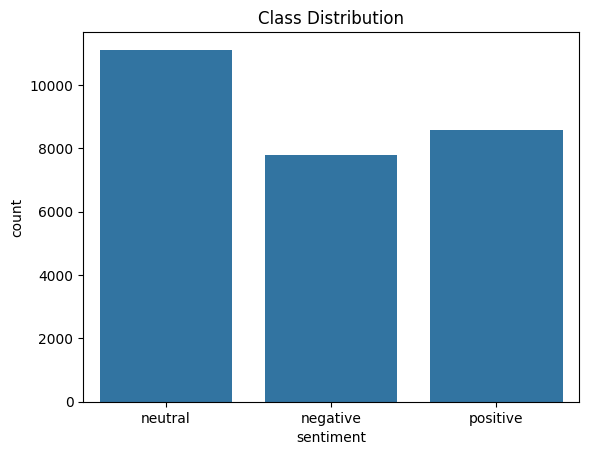

In [4]:
print(train_df.isnull().sum())
print(train_df.dtypes)

sns.countplot(x='sentiment', data=train_df)
plt.title('Class Distribution')
plt.show()

### N-gram Analysis (Bigrams & Trigrams)

In [5]:
def get_top_ngrams(corpus, n=2, top_k=10):
    all_ngrams = []
    for text in corpus:
        tokens = nltk.word_tokenize(str(text).lower())
        all_ngrams.extend([" ".join(gram) for gram in ngrams(tokens, n)])
    return Counter(all_ngrams).most_common(top_k)


print("Top 10 Bigrams in Positive Comments:")
print(
    get_top_ngrams(
        train_df[train_df["sentiment"] == "positive"]["text"], n=2, top_k=10
    )
)

print("\nTop 10 Trigrams in Negative Comments:")
print(
    get_top_ngrams(
        train_df[train_df["sentiment"] == "negative"]["text"], n=3, top_k=10
    )
)

Top 10 Bigrams in Positive Comments:
[('! !', 1794), ('` s', 1373), ('i `', 852), ('* *', 702), ('` t', 612), ('` m', 574), ('. i', 456), ('! i', 433), ('http :', 413), ('i love', 412)]

Top 10 Trigrams in Negative Comments:
[('* * *', 1160), ('i ` m', 902), ('! ! !', 739), ('it ` s', 379), ('can ` t', 342), ('don ` t', 341), ('i don `', 185), ('i can `', 174), ('didn ` t', 134), ('. i `', 124)]


### Word Clouds by Sentiment

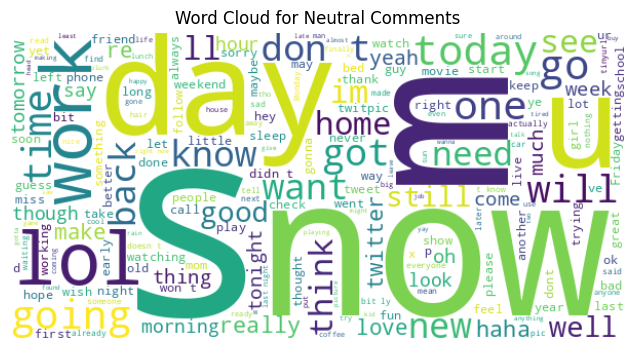

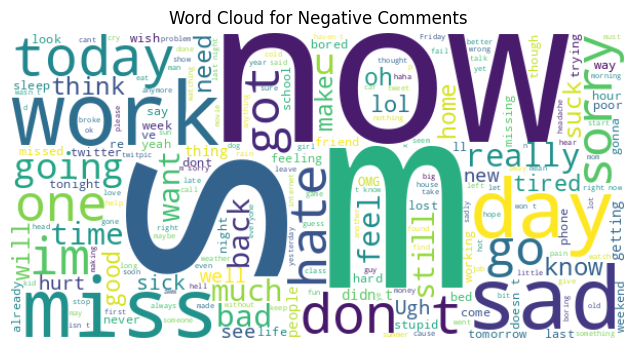

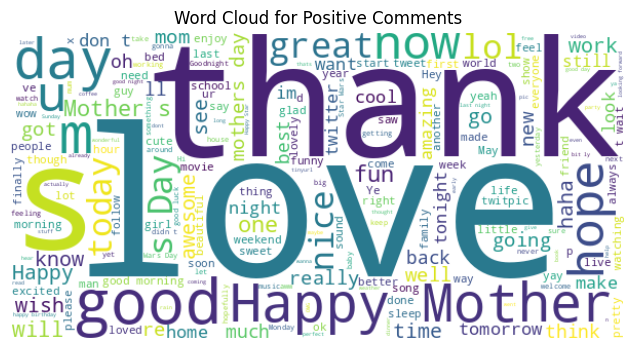

In [6]:
for sentiment in train_df["sentiment"].unique():
    text = " ".join(train_df[train_df["sentiment"] == sentiment]["text"].dropna().astype(str))
    wc = WordCloud(width=600, height=300, background_color="white").generate(text)
    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {sentiment.capitalize()} Comments")
    plt.show()

### Sentiment Lexicon Checks (using NLTK's opinion_lexicon)

In [7]:
pos_words = set(opinion_lexicon.positive())
neg_words = set(opinion_lexicon.negative())


def lexicon_sentiment_score(text):
    tokens = nltk.word_tokenize(str(text).lower())
    pos_count = sum(1 for t in tokens if t in pos_words)
    neg_count = sum(1 for t in tokens if t in neg_words)
    return pos_count, neg_count


train_df[["pos_lexicon", "neg_lexicon"]] = train_df["text"].apply(
    lambda x: pd.Series(lexicon_sentiment_score(x))
)

### Visualize lexicon scores by sentiment

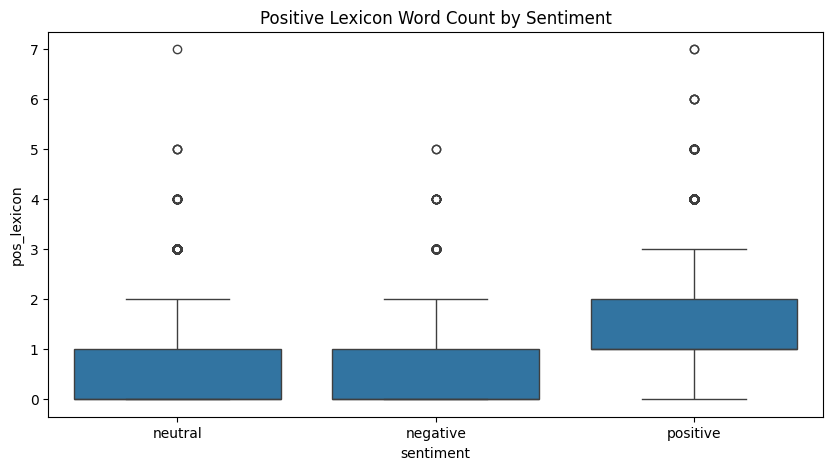

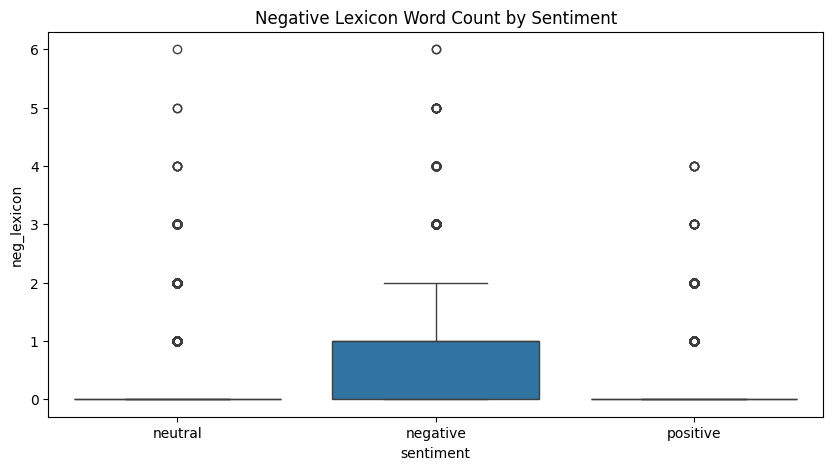

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="sentiment", y="pos_lexicon", data=train_df)
plt.title("Positive Lexicon Word Count by Sentiment")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x="sentiment", y="neg_lexicon", data=train_df)
plt.title("Negative Lexicon Word Count by Sentiment")
plt.show()

### Comment length analysis

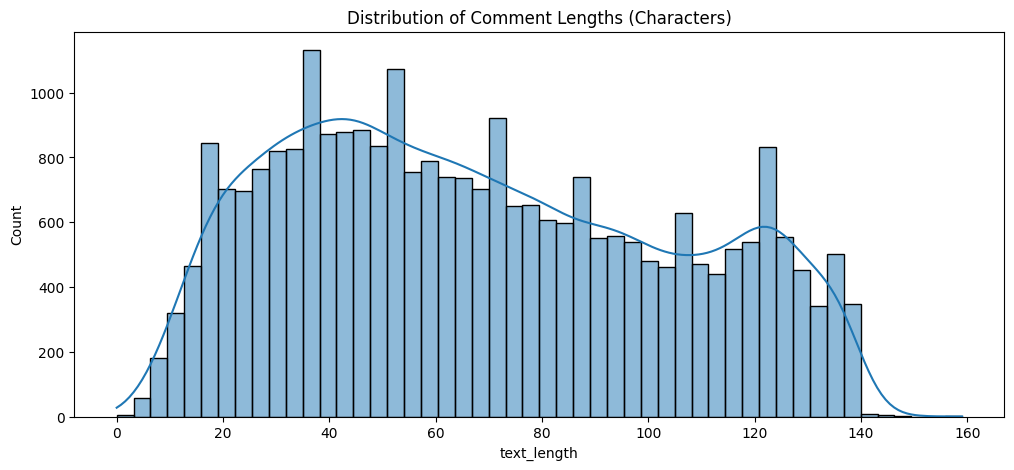

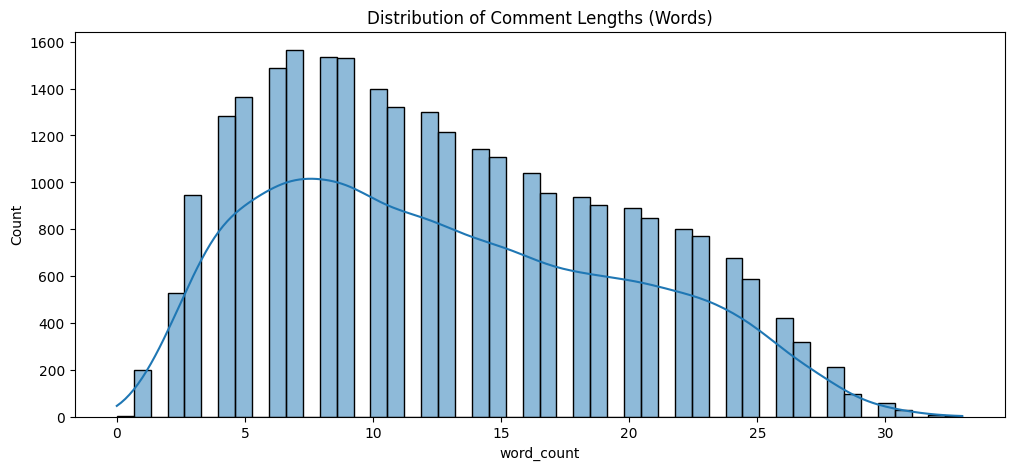

Comments with special characters: 13751


In [9]:

train_df['text_length'] = train_df['text'].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)

plt.figure(figsize=(12,5))
sns.histplot(train_df['text_length'], bins=50, kde=True)
plt.title('Distribution of Comment Lengths (Characters)')
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(train_df['word_count'], bins=50, kde=True)
plt.title('Distribution of Comment Lengths (Words)')
plt.show()

# Check for special characters/emoticons
def has_special(text):
    return bool(re.search(r'[^\w\s,.!?]', text))
train_df['has_special'] = train_df['text'].apply(lambda x: has_special(str(x)) if pd.notnull(x) else False)
print('Comments with special characters:', train_df['has_special'].sum())

## Text Preprocessing and BERT Setup

In [10]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

EMOTICONS = {
    r"(:\)|:-\)|:d|=])": " positive_emoji ",
    r"(:\(|:-\()": " negative_emoji ",
    r"(<3|❤|♥)": " positive_emoji ",
    r"(;-?\))": " wink_emoji ",
    r"(:/|:-/)": " skeptical_emoji ",
}

custom_stopwords = set([
    "would", "could", "also", "one", "get", "like", "even", "us", "im", "dont"
])

def preprocess_text_advanced(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # Replace emoticons and symbols
    for pattern, repl in EMOTICONS.items():
        text = re.sub(pattern, repl, text)
    # Remove URLs and HTML
    text = re.sub(r"http\S+|www\S+|<.*?>", "", text)
    # Handle negations (join not + word)
    text = re.sub(r"\bnot\b[\s]+(\w+)", r"not_\1", text)
    # Join common bigrams/trigrams if needed (example: "very good" → "very_good")
    text = re.sub(r"\bvery good\b", "very_good", text)
    text = re.sub(r"\bnot good\b", "not_good", text)
    # Remove special characters except punctuation
    text = re.sub(r"[^\w\s,.!?]", "", text)
    # Tokenize
    tokens = nltk.word_tokenize(text)
    # Remove stopwords (NLTK + custom)
    tokens = [
        t for t in tokens
        if t not in stop_words and t not in custom_stopwords and len(t) > 2
    ]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# Apply to your data
train_df["clean_text"] = train_df["text"].apply(preprocess_text_advanced)
test_df["clean_text"] = test_df["text"].apply(preprocess_text_advanced)

train_df[["pos_lexicon", "neg_lexicon"]] = train_df["clean_text"].apply(
    lambda x: pd.Series(lexicon_sentiment_score(x))
)
test_df[["pos_lexicon", "neg_lexicon"]] = test_df["clean_text"].apply(
    lambda x: pd.Series(lexicon_sentiment_score(x))
)
display(train_df[["text", "clean_text"]].head())

,text,clean_text
0,"I`d have responded, if I were going",responded going
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad miss san diego
2,my boss is bullying me...,bos bullying ...
3,what interview! leave me alone,interview leave alone
4,"Sons of ****, why couldn`t they put them on t...",son couldnt put release already bought


### Encode sentiment labels

In [11]:
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {v: k for k, v in label2id.items()}
train_df['label'] = train_df['sentiment'].map(label2id)

### Initialize BERT tokenizer

In [12]:
# tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

def tokenize_function(examples):
    return tokenizer(examples, padding='max_length', truncation=True, max_length=128)

# Tokenize the data
train_encodings = tokenizer(list(train_df['clean_text']), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_df['clean_text']), truncation=True, padding=True, max_length=128)

## Dataset Preparation and Model Training

In [13]:
class CommentDataset(Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.encodings['input_ids'])

In [14]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["clean_text"],
    train_df["label"],
    test_size=0.15,
    random_state=42,
    stratify=train_df["label"],
)

train_encodings = tokenizer(
    list(train_texts), truncation=True, padding=True, max_length=128
)
val_encodings = tokenizer(
    list(val_texts), truncation=True, padding=True, max_length=128
)

train_dataset = CommentDataset(train_encodings, list(train_labels))
val_dataset = CommentDataset(val_encodings, list(val_labels))

In [15]:
# model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)
model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=3)

model.to(device)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [16]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    fp16=torch.cuda.is_available(),
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
        "precision": precision_score(labels, preds, average="weighted"),
        "recall": recall_score(labels, preds, average="weighted"),
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

In [17]:
trainer.train()

Step,Training Loss
50,1.079100
100,0.983800
150,0.801700
200,0.802300
250,0.786500
300,0.794800
350,0.786800
400,0.808700
450,0.764200
500,0.720800


TrainOutput(global_step=4380, training_loss=0.5918704842867917, metrics={'train_runtime': 136.2089, 'train_samples_per_second': 514.46, 'train_steps_per_second': 32.156, 'total_flos': 1980581113013580.0, 'train_loss': 0.5918704842867917, 'epoch': 3.0})

## Model Evaluation and Submission Export

We will evaluate the model's accuracy and generate predictions for the test set, exporting them in the required CSV format.

In [18]:
eval_results = trainer.evaluate()
print(f"Training Accuracy: {eval_results['eval_accuracy']:.4f}")

Training Accuracy: 0.7623


In [19]:
test_dataset = CommentDataset(test_encodings)

test_preds = trainer.predict(test_dataset)
test_pred_labels = test_preds.predictions.argmax(axis=1)
test_df["sentiment"] = [id2label[i] for i in test_pred_labels]

In [20]:
print(test_df.columns)
submission = test_df[["ID", "sentiment"]]
submission.to_csv("submission.csv", index=False)
print("Submission file saved as submission.csv")

Index(['ID', 'text', 'clean_text', 'pos_lexicon', 'neg_lexicon', 'sentiment'], dtype='object')
Submission file saved as submission.csv


## Result of other models

- Random Forest with char_tfidf_large: 0.7130
- LSTM: 0.6827
- BiLSTM: 0.6814
- BERT: 0.7621